In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from rdkit import Chem
from rdkit.Chem import Draw

# Aggregation States

A solution is a homogeneous mixture where a solute (i.e. drug molecules) is dispersed in a solvent (e.g., water). Aggregation states refer to how solute particles group together or disperse in the solvent. This affects solubility and bioavailability, and is another source of alteoric uncertainty.

Aggregation can range from individual molecules (monomers) to clusters (aggregates) or larger particles, and it's affected by a wide range of conditions including solvent concentration, temperature, and molecular properties.

1. **Monomers (True Solution)**: Individual molecules (<1 nm) below CMC.  
   *Example: Dissolved ibuprofen.*

2. **Micelles (Colloidal Dispersion)**: Clusters (1 nm–1 μm) above CMC.  
   *Example: Ibuprofen micelles in water.*

3. **Suspensions**: Large clumps (>1 μm) that settle out of solution.

In AQSolDB, micelles can increase apparent solubility but may also trap drugs, affecting their delivery.

### Critical Micelle Concentration (CMC)

CMC is the concentration above which amphiphilic molecules (with both hydrophobic and hydrophilic parts) form micelles instead of remaining as individual **monomers**. 

- Below CMC: molecules are dispersed as monomers 
- Above CMC: molecules cluster together to minimise the exposure of their hydrophobic regions to water.


### Drivers of aggregation

- **Hydrophobic Effect**: Drives micelle formation as hydrophobic parts of molecules avoid water, reducing the system's free energy. This can be described by the equation: $\Delta G = RT \ln(\text{CMC})$,  
  where *R* is the gas constant, *T* is temperature, and *CMC* is in *mol/L*.

- **Lennard-Jones Potential**: Models the attraction (van der Waals) and repulsion between molecules:  
  $$ V(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right] $$
  - $r$: Distance between molecules  
  - $\epsilon$: Depth of the energy well (strength of attraction)  
  - $\sigma$: Distance at which the potential is zero

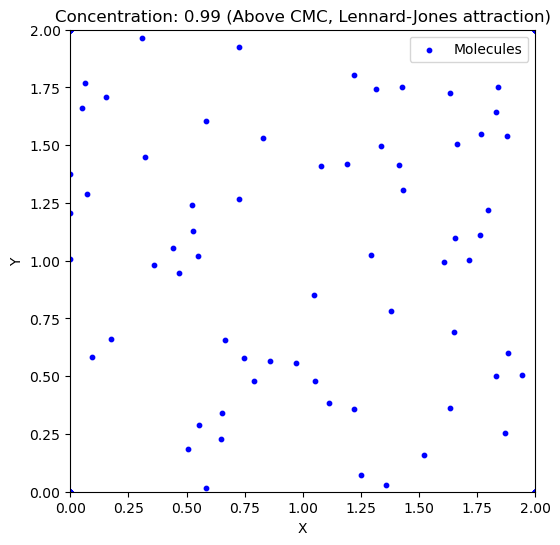

In [ ]:
np.random.seed(42)
n_particles = 100
positions = np.random.rand(n_particles, 2) * 2  # Positions in [0,2]x[0,2]
velocity = np.zeros((n_particles, 2))
epsilon = 0.1  # Lennard-Jones well depth (attraction)
sigma = 0.1  # Lennard-Jones distance parameter
min_dist = sigma * 0.7  # Minimum allowed distance between particles, (attraction -> repulsion)
cmc_concentration = 0.5  # Pretend CMC (arbitrary units, 0 to 1)
dt = 0.05
repulsion_strength = 1e-12

fig, ax = plt.subplots(figsize=(6, 6))
scat = ax.scatter(positions[:, 0], positions[:, 1], s=10, color='blue', label='Molecules')
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Monomers to Micelles in Solution')
ax.legend()

# F = -dV/dr = 24ε[2(σ/r)^13 - (σ/r)^7]
def lennard_jones_force(r, epsilon, sigma):
    r = max(r, 1e-12)
    term = (sigma / r)
    return 24 * epsilon * (2 * term**13 - term**7) / r

# Raise conc. over frames 0 -> 1
def update(frame):
    global positions, velocity
    concentration = frame / 200 

    for i in range(n_particles):
        forces = np.zeros(2)
        for j in range(n_particles):
            if i != j:
                diff = positions[i] - positions[j]
                dist = np.sqrt(np.sum(diff**2))

                # Above CMC, lennard jones attraction
                if concentration > cmc_concentration:  
                    if dist < 0.5:
                        force_mag = lennard_jones_force(dist, epsilon, sigma)
                        forces += force_mag * diff /  max(dist, 1e-12)
                else:
                    forces += np.random.normal(0, 0.1, 2)  # Brownian motion

                # Repulsion
                if dist < min_dist:
                    repulse = (min_dist - dist) * repulsion_strength
                    forces += repulse * diff / (dist + 1e-8)
                    continue 

        velocity[i] += dt * forces  # Update velocity
        velocity[i] *= 0.6  # Damping
        positions[i] += dt * velocity[i]  # Update position
        positions[i] = np.clip(positions[i], 0, 2)  # Clip positions to domain

    scat.set_offsets(positions)
    ax.set_title(f'Concentration: {concentration:.2f} {"(Below CMC, Brownian motion)" if concentration < cmc_concentration else "(Above CMC, Lennard-Jones attraction)"}')
    return scat,

ani = FuncAnimation(fig, update, frames=200, interval=50, blit=True)
ani.save('aggregation.gif', writer='pillow', fps=20)